# O4 rates

## Get data from the 'GWTC-4.0: O4a Search Sensitivity Estimates'

- This will be use to compute the observed SNR threhold
- psd from this data will be used to compute the SNR of the events and determine if they are detectable or not.

In [5]:
## original catalogue data: https://zenodo.org/records/16740117
## !wget https://zenodo.org/records/16740117/files/samples-rpo4a_v2_20250503133839UTC-1366933504-23846400.hdf?download=1

# Reduce the data to a smaller JSON file for testing purpose
import h5py
# replace the path with your own path to the downloaded hdf file
with h5py.File('/Users/phurailatpamhemantakumar/Downloads/samples-rpo4a_v2_20250503133839UTC-1366933504-23846400.hdf', 'r') as obj:
    attrs = dict(obj.attrs.items())
    events = obj['events'][:]

gstlal_far = events['gstlal_far']
observed_snr_net = events['observed_snr_net']
z = events['z']
mass1_source = events['mass1_source']
mass2_source = events['mass2_source']
luminosity_distance = events['luminosity_distance']
dict_to_save = dict(
    gstlal_far=gstlal_far,
    observed_snr_net=observed_snr_net,
    z=z,
    mass1_source=mass1_source,
    mass2_source=mass2_source,
    luminosity_distance=luminosity_distance
)
from gwsnr.utils import append_json
append_json('injection_data_O4.json', dict_to_save, replace=True);

In [9]:
# Getting the O4a monthly PSDs and creating the effective PSD for H1 and L1 detectors and creating a common PSD for O4a run
import gzip
import time
import urllib.request
from pathlib import Path

import numpy as np

months = [
    "2023_05",
    "2023_06",
    "2023_07",
    "2023_08",
    "2023_09",
    "2023_10",
    "2023_11",
    "2023_12",
    "2024_01",
]

# Wall-time weighting: May 2023 through January 2024
days = np.array([31, 30, 31, 31, 30, 31, 30, 31, 31], dtype=float)
weights = days / days.sum()

base_url = "https://zenodo.org/records/16740117/files"
cache_dir = Path("o4a_monthly_psds")
cache_dir.mkdir(exist_ok=True)


def download_monthly_psd(month, detector, max_attempts=5):
    """Download, cache, validate, and return one monthly PSD."""

    detector_code = {"H1": "H", "L1": "L"}[detector]

    filename = f"psd-O4-{month}_v1-{detector_code}.txt.gz"
    url = f"{base_url}/{filename}?download=1"
    cache_file = cache_dir / filename
    partial_file = cache_dir / f"{filename}.part"

    for attempt in range(1, max_attempts + 1):
        try:
            if not cache_file.exists():
                print(f"Downloading {filename} (attempt {attempt}/{max_attempts})")
                request = urllib.request.Request(
                    url, headers={"User-Agent": "gwsnr-psd-downloader/1.0"}
                )

                with urllib.request.urlopen(request, timeout=120) as response:
                    expected_size = response.headers.get("Content-Length")
                    expected_size = int(expected_size) if expected_size else None

                    with partial_file.open("wb") as output:
                        while True:
                            chunk = response.read(64 * 1024)
                            if not chunk:
                                break
                            output.write(chunk)

                actual_size = partial_file.stat().st_size
                if expected_size is not None and actual_size != expected_size:
                    raise IOError(
                        f"Incomplete download for {filename}: "
                        f"received {actual_size} of {expected_size} bytes"
                    )

                partial_file.replace(cache_file)

            # Reading the full gzip stream also verifies its CRC.
            with gzip.open(cache_file, "rt") as psd_file:
                data = np.loadtxt(psd_file, skiprows=1)

            if data.ndim != 2 or data.shape[1] != 2:
                raise ValueError(f"Invalid PSD table in {filename}")
            if not np.all(np.isfinite(data)) or np.any(data[:, 1] <= 0):
                raise ValueError(f"Invalid PSD values in {filename}")

            return data[:, 0], data[:, 1]

        except Exception:
            partial_file.unlink(missing_ok=True)
            cache_file.unlink(missing_ok=True)
            if attempt == max_attempts:
                raise
            time.sleep(min(2**attempt, 10))


def create_effective_psd(detector, output_file):
    monthly_psds = []
    frequency = None

    for month in months:
        freq_i, psd_i = download_monthly_psd(month, detector)

        if frequency is None:
            frequency = freq_i
        else:
            if not np.array_equal(frequency, freq_i):
                raise ValueError(
                    f"Frequency grid differs for {month}, {detector}"
                )

        monthly_psds.append(psd_i)

    monthly_psds = np.asarray(monthly_psds)

    # Harmonic mean appropriate for averaging rho^2
    effective_psd = 1.0 / np.sum(
        weights[:, None] / monthly_psds,
        axis=0,
    )

    np.savetxt(
        output_file,
        np.column_stack([frequency, effective_psd]),
    )

    return frequency, effective_psd

create_effective_psd(
    "H1",
    "O4a_common_H1_psd.txt",
)

create_effective_psd(
    "L1",
    "O4a_common_L1_psd.txt",
)

In [10]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from gwsnr.threshold import SNRThresholdFinder

from gwsnr.utils import get_param_from_json
params = get_param_from_json('injection_data_O4.json')

gstlal_far = params['gstlal_far']
observed_snr_net = params['observed_snr_net']
z = params['z']
mass1_source = params['mass1_source']

test = SNRThresholdFinder(
    catalog_file = None,
    # below are all default values. You can omit them if you want. 
    npool=4,
    original_detection_statistic = dict(
                key_name='gstlal_far',
                threshold=1,  # 1 per year
                parameter=gstlal_far,
            ),
    projected_detection_statistic = dict(
                key_name='observed_snr_net',
                threshold=None, # to be determined
                threshold_search_bounds=(8, 14),
                parameter=observed_snr_net,
            ),
    parameters_to_fit = dict(
        key_name = 'z',
        parameter=z,
    ),
    sample_size=20000,
    selection_range = dict(
        key_name = 'mass1_source',
        range = (1, 3), # in solar masses
        parameter = mass1_source,
    ),
)

best_thr, _, _, _, _ = test.find_threshold(iteration=10, print_output=True, no_multiprocessing=True)

snr_th, snr_th_net = best_thr, best_thr
print(f"Best threshold for SNR: {snr_th:.2f}, Best threshold for SNR_net: {snr_th_net:.2f}")

100%|███████████████████████████████████████████████████████████████| 10/10 [00:05<00:00,  1.89it/s]

Best SNR threshold: 11.45
Best threshold for SNR: 11.45, Best threshold for SNR_net: 11.45


snr_th_net = 11.45 (L1+H1)

In [1]:
from ler import LeR
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import LambdaCDM


ler = LeR(
    npool = 6,
    z_min = 0.0,
    z_max = 10.0,
    event_type = 'BBH',
    lens_type = 'epl_shear_galaxy',
    cosmology = LambdaCDM(H0=70.0, Om0=0.3, Ode0=0.7, Tcmb0=0.0, Neff=3.04, m_nu=None, Ob0=0.0), #flat LambdaCDM cosmology 
    pdet_finder =None, # gwsnr by default
    json_file_names = dict(
        ler_params = 'ler_params.json',
        unlensed_param = 'unlensed_param.json',
        unlensed_param_detectable = 'unlensed_param_detectable.json',
        lensed_param = 'lensed_param.json',
        lensed_param_detectable = 'lensed_param_detectable.json',
    ),
    interpolator_directory = '../interpolator_json',
    ler_directory = './ler_data',

    # LeR also takes other CBCSourceParameterDistribution class input arguments as kwargs, as follows:
    gw_functions = dict(
        merger_rate_density = 'merger_rate_density_madau_dickinson_belczynski_ng',
        param_sampler_type = 'gw_parameters_rvs',
    ),
    gw_functions_params = dict(
        merger_rate_density = {'param_name': 'merger_rate_density', 'function_type': 'merger_rate_density_madau_dickinson_belczynski_ng', 'R0': 1.9e-08, 'alpha_F': 2.57, 'beta_F': 5.83, 'c_F': 3.36},
        param_sampler_type = None,
    ),
    gw_priors = dict(
        zs = 'merger_rate_density_based_source_redshift',
        mass_1_source = 'broken_powerlaw_plus_2peaks',
        mass_ratio = 'powerlaw_with_smoothing',
        mass_2_source = None,
        geocent_time = 'uniform',
        ra = 'uniform',
        dec = 'sampler_cosine',
        phase = 'uniform',
        psi = 'uniform',
        theta_jn = 'sampler_sine',
        a_1 = 'truncated_normal',
        a_2 = 'truncated_normal',
        tilt_1 = 'gaussian_plus_isotropic',
        tilt_2 = 'gaussian_plus_isotropic_joint',
        phi_12 = 'uniform',
        phi_jl = 'uniform',
    ),
    gw_priors_params = dict(
        zs = None,
        mass_1_source = {'param_name': 'mass_1_source', 'sampler_type': 'broken_powerlaw_plus_2peaks', 'lam_0': 0.361, 'lam_1': 0.586, 'mpp_1': 9.764, 'sigpp_1': 0.649, 'mpp_2': 32.763, 'sigpp_2': 3.918, 'mlow_1': 5.059, 'delta_m_1': 4.321, 'break_mass': 35.622, 'alpha_1': 1.728, 'alpha_2': 4.512, 'mmax': 300.0, 'normalization_size': 500},
        mass_ratio = {'param_name': 'mass_ratio', 'sampler_type': 'powerlaw_with_smoothing', 'q_min': 0.01, 'q_max': 1.0, 'mlow_2': 3.551, 'mmax': 300.0, 'beta': 1.171, 'delta_m': 4.91, 'mmin': 3.551},
        mass_2_source = None,
        geocent_time = {'param_name': 'geocent_time', 'sampler_type': 'uniform', 'x_min': 1238166018, 'x_max': 1269702018},
        ra = {'param_name': 'ra', 'sampler_type': 'uniform', 'x_min': 0.0, 'x_max': 6.283185307179586},
        dec = {'param_name': 'dec', 'sampler_type': 'sampler_cosine', 'x_min': -1.5707963267948966, 'x_max': 1.5707963267948966},
        phase = {'param_name': 'phase', 'sampler_type': 'uniform', 'x_min': 0.0, 'x_max': 6.283185307179586},
        psi = {'param_name': 'psi', 'sampler_type': 'uniform', 'x_min': 0.0, 'x_max': 3.141592653589793},
        theta_jn = {'param_name': 'theta_jn', 'sampler_type': 'sampler_sine', 'x_min': 0.0, 'x_max': 3.141592653589793},
        a_1 = {'param_name': 'a_1', 'sampler_type': 'truncated_normal', 'x_min': 0.0, 'x_max': 1.0, 'mu': 0.085, 'sigma': 0.33},
        a_2 = {'param_name': 'a_2', 'sampler_type': 'truncated_normal', 'x_min': 0.0, 'x_max': 1.0, 'mu': 0.085, 'sigma': 0.33},
        tilt_1 = {'param_name': 'tilt_1', 'sampler_type': 'gaussian_plus_isotropic', 'tilt_1_min': 0.0, 'tilt_1_max': 3.141592653589793, 'mu_t': 0.426, 'sigma_t': 1.222, 'zeta': 0.652},
        tilt_2 = {'param_name': 'tilt_2', 'sampler_type': 'gaussian_plus_isotropic_joint', 'tilt_2_min': 0.0, 'tilt_2_max': 3.141592653589793, 'mu_t': 0.426, 'sigma_t': 1.222, 'zeta': 0.652},
        phi_12 = {'param_name': 'phi_12', 'sampler_type': 'uniform', 'x_min': 0, 'x_max': 6.283185307179586},
        phi_jl = {'param_name': 'phi_jl', 'sampler_type': 'uniform', 'x_min': 0, 'x_max': 6.283185307179586},
    ),
    spin_zero = False,
    spin_precession = True,

    # LeR also takes other LensGalaxyParameterDistribution class input arguments as kwargs, as follows:
    lens_functions = dict(
        param_sampler_type = 'epl_shear_sl_parameters_rvs',
        cross_section_based_sampler = 'importance_sampler_partial',
        optical_depth = 'optical_depth_numerical',
        cross_section = 'cross_section_epl_shear_njit',
    ),
    lens_functions_params = dict(
        param_sampler_type = None,
        cross_section_based_sampler = {'n_prop': 50, 'threshold_factor': 0.0001, 'sigma_min': 100.0, 'sigma_max': 400.0, 'q_min': 0.2, 'q_max': 1.0, 'phi_min': 0.0, 'phi_max': 6.283185307179586, 'gamma_min': 1.4, 'gamma_max': 2.7, 'shear_min': -0.22, 'shear_max': 0.2},
        optical_depth = {'param_name': 'optical_depth', 'function_type': 'optical_depth_numerical'},
        cross_section = {'num_th': 500, 'maginf': -100.0},
    ),
    lens_priors = dict(
        zs_sl = 'strongly_lensed_source_redshift',
        lens_redshift_sl = 'lens_redshift_strongly_lensed_numerical',
        lens_redshift = 'lens_redshift_intrinsic_numerical',
        velocity_dispersion = 'velocity_dispersion_ewoud',
        axis_ratio = 'rayleigh',
        axis_rotation_angle = 'uniform',
        external_shear1 = 'normal',
        external_shear2 = 'normal',
        density_profile_slope = 'normal',
    ),
    lens_priors_params = dict(
        zs_sl = {'tau_approximation': True},
        lens_redshift_sl = {'param_name': 'lens_redshift_sl', 'sampler_type': 'lens_redshift_strongly_lensed_numerical', 'lens_type': 'epl_shear_galaxy', 'integration_size': 50000, 'use_multiprocessing': False, 'cross_section_epl_shear_interpolation': False},
        lens_redshift = None,
        velocity_dispersion = {'param_name': 'velocity_dispersion', 'sampler_type': 'velocity_dispersion_ewoud', 'sigma_min': 100.0, 'sigma_max': 400.0, 'alpha': 0.94, 'beta': 1.85, 'phistar': np.float64(0.02099), 'sigmastar': 113.78},
        axis_ratio = {'param_name': 'axis_ratio', 'sampler_type': 'rayleigh', 'q_min': 0.2, 'q_max': 1.0},
        axis_rotation_angle = {'param_name': 'axis_rotation_angle', 'sampler_type': 'uniform', 'x_min': 0.0, 'x_max': 6.283185307179586},
        external_shear1 = {'param_name': 'external_shear1', 'sampler_type': 'normal', 'mu': 0.0, 'sigma': 0.05},
        external_shear2 = {'param_name': 'external_shear2', 'sampler_type': 'normal', 'mu': 0.0, 'sigma': 0.05},
        density_profile_slope = {'param_name': 'density_profile_slope', 'sampler_type': 'normal', 'mu': 1.99, 'sigma': 0.149},
    ),

    # LeR also takes other ImageProperties class input arguments as kwargs, as follows:
    n_min_images = 2,
    n_max_images = 4,
    time_window = 31536000.0,
    include_effective_parameters = False,
    lens_model_list = ['EPL_NUMBA', 'SHEAR'],
    image_properties_function = 'image_properties_epl_shear_njit',
    multiprocessing_verbose = True,
    include_redundant_parameters = False,

    # LeR also takes other gwsnr.GWSNR input arguments as kwargs, as follows:
    snr_method = 'interpolation_aligned_spins',
    gwsnr_verbose = True,
    pdet_kwargs = dict(
        snr_th = 10.0,
        snr_th_net = 10.0,
        pdet_type = 'probability_distribution',
        distribution_type = 'noncentral_chi2',
        include_optimal_snr = False,
        include_observed_snr = False,
    ),
    mtot_min = 1.0,
    mtot_max = 500.0,
    ratio_min = 0.1,
    ratio_max = 1.0,
    spin_max = 0.99,
    mtot_resolution = 200,
    ratio_resolution = 20,
    spin_resolution = 10,
    batch_size_interpolation = 1000000,
    interpolator_dir = '../interpolator_json',
    sampling_frequency = 2048.0,
    waveform_approximant = 'IMRPhenomXPHM',
    frequency_domain_source_model = 'lal_binary_black_hole',
    minimum_frequency = 20.0,
    mtot_cut = False,
    psds = dict(
        L1 = 'O4a_common_L1_psd.txt',
        H1 = 'O4a_common_H1_psd.txt',
    ),
    # ifos = ['L1', 'H1'],
    snr_recalculation = True,
    snr_recalculation_range = [6, 14],
    snr_recalculation_waveform_approximant = 'IMRPhenomXPHM',
)


Initializing LeR class...


Initializing LensGalaxyParameterDistribution class...


Initializing OpticalDepth class

comoving_distance interpolator will be loaded from ../interpolator_json/comoving_distance/comoving_distance_0.json
angular_diameter_distance interpolator will be loaded from ../interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
angular_diameter_distance interpolator will be loaded from ../interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
differential_comoving_volume interpolator will be loaded from ../interpolator_json/differential_comoving_volume/differential_comoving_volume_0.json
using ler available velocity dispersion function : velocity_dispersion_ewoud
velocity_dispersion_ewoud interpolator will be loaded from ../interpolator_json/velocity_dispersion/velocity_dispersion_ewoud_0.json
using ler available axis_ratio function : rayleigh
rayleigh interpolator will be loaded from ../interpolator_json/axis_ratio/raylei

In [29]:
detectable_rate_unlensed, unlensed_param_detectable_n = ler.selecting_n_unlensed_detectable_events(
    size=100000,                          # Target number of detectable events
    batch_size=1000000,                   # Events per batch
    stopping_criteria=dict(
        relative_diff_percentage=0.1,    # Stop when rate change < 0.1%
        number_of_last_batches_to_check=4  # Check last 4 batches for convergence
    ),
    pdet_threshold=0.5,                  # Probability threshold for detection
    resume=True,                         # Resume from previous state if available
    output_jsonfile='unlensed_params_n_detectable_gwtc4.json',  # Output file for detectable events
    meta_data_file='meta_unlensed_gwtc4.json', # Store metadata (rates per batch)
    pdet_type='boolean',                 # Detection type: 'boolean' or 'float'
    trim_to_size=False,                  # Keep all events found until convergence
)

print(f"\n=== Unlensed N-Event Sampling Results ===")
print(f"Detectable event rate: {detectable_rate_unlensed:.4e} events per year")
print(f"Total detectable events collected: {len(unlensed_param_detectable_n['zs'])}")
# expected time: 12.9s

stopping criteria set to when relative difference of total rate for the last 4 cumulative batches is less than 0.1%.
sample collection will stop when the stopping criteria is met and number of detectable events exceeds the specified size.
Resuming from 50329 detectable events.
percentage difference of total rate for the last 4 cumulative batches = [0.0355163  0.03846689 0.0411905  0.        ]
stopping criteria of rate relative difference of 0.1% for the last 4 cumulative batches reached.
collected number of detectable events =  50329


100%|██████████████████████████████████████████████████████████| 8094/8094 [00:09<00:00, 835.85it/s]


collected number of detectable events (batch) =  1868
collected number of detectable events (cumulative) =  52197
total number of events =  28000000
batch rate (yr^-1): 171.07854256766112
total rate (yr^-1): 170.7285616091352
percentage difference of total rate for the last 4 cumulative batches = [0.04605629 0.0487797  0.00759232 0.        ]
stopping criteria of rate relative difference of 0.1% for the last 4 cumulative batches reached.


100%|██████████████████████████████████████████████████████████| 8138/8138 [00:09<00:00, 851.93it/s]


collected number of detectable events (batch) =  1825
collected number of detectable events (cumulative) =  54022
total number of events =  29000000
batch rate (yr^-1): 167.1404390717246
total rate (yr^-1): 170.6048332457762
percentage difference of total rate for the last 4 cumulative batches = [0.02370829 0.06492554 0.07252336 0.        ]
stopping criteria of rate relative difference of 0.1% for the last 4 cumulative batches reached.


...

[gwsnr] Waveform generation failed (likely fCut <= f_min for high-mass systems). Returning SNR=0 for those samples. If this happens often, try again with input argument: mtot_cut=True (and/or lower mtot_max).


100%|██████████████████████████████████████████████████████████| 8230/8230 [00:10<00:00, 773.19it/s]


collected number of detectable events (batch) =  1879
collected number of detectable events (cumulative) =  98848
total number of events =  53000000
batch rate (yr^-1): 172.085964392203
total rate (yr^-1): 170.8089751497734
percentage difference of total rate for the last 4 cumulative batches = [0.03949498 0.01354823 0.01437716 0.        ]
stopping criteria of rate relative difference of 0.1% for the last 4 cumulative batches reached.


100%|██████████████████████████████████████████████████████████| 8262/8262 [00:10<00:00, 816.09it/s]


collected number of detectable events (batch) =  1872
collected number of detectable events (cumulative) =  100720
total number of events =  54000000
batch rate (yr^-1): 171.44487777658543
total rate (yr^-1): 170.82075112434399
percentage difference of total rate for the last 4 cumulative batches = [0.02044106 0.02126993 0.00689376 0.        ]
stopping criteria of rate relative difference of 0.1% for the last 4 cumulative batches reached.
Given size=100000 reached

stored detectable unlensed params in ./ler_data/unlensed_params_n_detectable_gwtc4.json
stored meta data in ./ler_data/meta_unlensed_gwtc4.json

=== Unlensed N-Event Sampling Results ===
Detectable event rate: 1.7082e+02 events per year
Total detectable events collected: 100720


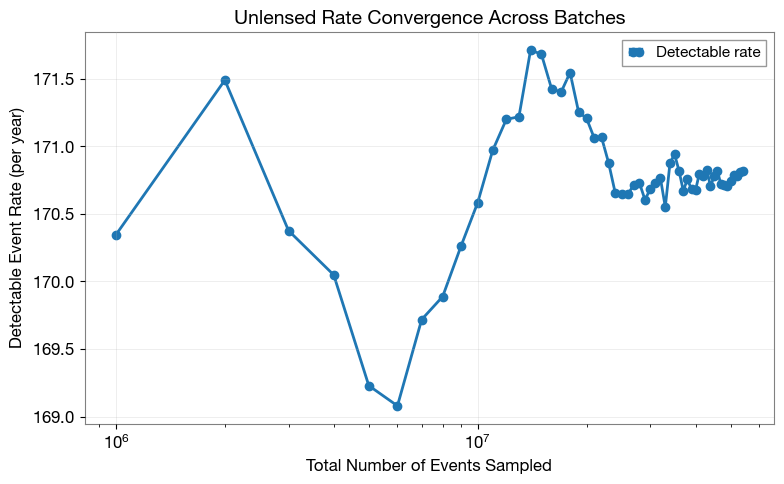

In [30]:
import matplotlib.pyplot as plt
from ler.utils import get_param_from_json

# Load metadata containing rates for each batch
meta_data = get_param_from_json(ler.ler_directory + '/meta_unlensed_gwtc4.json')

# Plot rate vs sampling size
plt.figure(figsize=(8, 5))
plt.plot(
    meta_data['events_total'],
    meta_data['total_rate'],
    'o-',
    linewidth=2,
    markersize=6,
    color='C0',
    label='Detectable rate'
)

plt.xlabel('Total Number of Events Sampled', fontsize=12)
plt.ylabel('Detectable Event Rate (per year)', fontsize=12)
plt.title('Unlensed Rate Convergence Across Batches', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.legend(fontsize=11)
plt.xscale('log')
plt.tight_layout()
plt.show()

In [31]:
import numpy as np

# Select rates from the last 4 batches
idx_converged = [-4, -3, -2, -1]
rates_converged = np.array(meta_data['total_rate'])[idx_converged]

if len(rates_converged) > 0:
    mean_rate = rates_converged.mean()
    
    print(f"=== Unlensed Rate Stability Analysis ===")
    print(f"Number of batches analyzed: {len(rates_converged)}")
    print(f"Mean rate: {mean_rate:.4e} events/year")
else:
    print("Not enough batches to assess convergence.")

# Update the rate with the converged mean
detectable_rate_unlensed = mean_rate

=== Unlensed Rate Stability Analysis ===
Number of batches analyzed: 4
Mean rate: 1.7080e+02 events/year


=== Unlensed Rate Statistical Uncertainty ===
Mean rate: 1.7082e+02 events/year
Standard deviation: 3.3423e+00 events/year


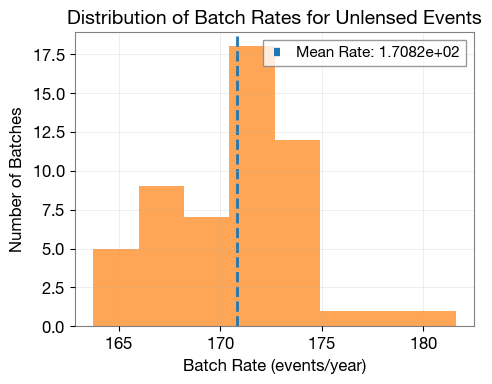

In [36]:
# statistical uncertainty
batch_rates = np.array(meta_data['batch_rate'])

mean_rate = batch_rates.mean()
std_rate = batch_rates.std()
print(f"=== Unlensed Rate Statistical Uncertainty ===")
print(f"Mean rate: {mean_rate:.4e} events/year")
print(f"Standard deviation: {std_rate:.4e} events/year")

# plot histogram of batch rates
plt.figure(figsize=(5, 4))
plt.hist(batch_rates, bins=8, color='C1', alpha=0.7)
plt.axvline(mean_rate, color='C0', linestyle='dashed', linewidth=2, label=f'Mean Rate: {mean_rate:.4e}')
plt.xlabel('Batch Rate (events/year)', fontsize=12)
plt.ylabel('Number of Batches', fontsize=12)
plt.title('Distribution of Batch Rates for Unlensed Events', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

## All events

In [5]:
unlensed_param_all_n = ler.unlensed_cbc_statistics(
    size=1000000,                          # Target number of unlensed events
    batch_size=1000000,                   # Events per batch
    resume=False,
    output_jsonfile='unlensed_params_all_gwtc4.json',  # Output file for all unlensed events
)

unlensed params will be stored in ./ler_data/unlensed_params_all_gwtc4.json
removing ./ler_data/unlensed_params_all_gwtc4.json if it exists
Batch no. 1
sampling gw source params...
calculating pdet...
Recalculating SNR for 8018 out of 1000000 samples in the SNR range of 6 to 14


100%|██████████████████████████████████████████████████████████| 8018/8018 [00:09<00:00, 829.81it/s]


saving all unlensed parameters in ./ler_data/unlensed_params_all_gwtc4.json 


In [6]:
_, unlensed_param_detectable_n = ler.unlensed_rate(
    unlensed_param='unlensed_params_all_gwtc4.json',
    pdet_threshold=0.5,
    pdet_type='boolean',
    output_jsonfile=None,
)

Getting unlensed_param from json file ./ler_data/unlensed_params_all_gwtc4.json...
total unlensed rate (yr^-1): 174.37555944798007
number of simulated unlensed detectable events: 1904
number of simulated all unlensed events: 1000000


### Mass

In [8]:
# load data 
from ler.utils import get_param_from_json
import numpy as np

# 500 samples from the 90% credible interval of the hyperparameters of the broken powerlaw plus 2 peaks model from GWTC-4
data = get_param_from_json("broken_powerlaw_plus_2peaks_hyperparameters.json")
# data

# # plot the corner plot of the hyperparameters
# from corner import corner
# labels = list(data.keys())
# # use column stacks
# data_ = np.column_stack([data[key] for key in labels])

# figure = corner(data_, labels=labels, show_titles=True)

In [19]:
loop_size = 500
lam_0_median=np.median(data["lam_0"])
lam_1_median=np.median(data["lam_1"])
mpp_1_median=np.median(data["mpp_1"])
sigpp_1_median=np.median(data["sigpp_1"])
mpp_2_median=np.median(data["mpp_2"])
sigpp_2_median=np.median(data["sigpp_2"])
mlow_1_median=np.median(data["mlow_1"])
delta_m_1_median=np.median(data["delta_m_1"])
break_mass_median=np.median(data["break_mass"])   
alpha_1_median=np.median(data["alpha_1"])
alpha_2_median=np.median(data["alpha_2"])

idx = np.random.choice(len(data["lam_0"]), size=loop_size, replace=False)
lam_0 = data["lam_0"][idx]
lam_1 = data["lam_1"][idx]
mpp_1 = data["mpp_1"][idx]
sigpp_1 = data["sigpp_1"][idx]
mpp_2 = data["mpp_2"][idx]
sigpp_2 = data["sigpp_2"][idx]
mlow_1 = data["mlow_1"][idx]
delta_m_1 = data["delta_m_1"][idx]
break_mass = data["break_mass"][idx]
alpha_1 = data["alpha_1"][idx]
alpha_2 = data["alpha_2"][idx]

In [13]:
from ler.gw_source_population import broken_powerlaw_plus_2peaks_pdf, mass_ratio_powerlaw_with_smoothing_pdf

# broken_powerlaw_plus_2peaks_pdf(
#     m1,
#     lam_0=0.361,
#     lam_1=0.586,
#     mpp_1=9.764,
#     sigpp_1=0.649,
#     mpp_2=32.763,
#     sigpp_2=3.918,
#     mlow_1=5.059,
#     delta_m_1=4.321,
#     break_mass=35.622,
#     alpha_1=1.728,
#     alpha_2=4.512,
#     mmax=300.0,
#     normalization_size=500,
# )

# mass_ratio_powerlaw_with_smoothing_pdf(
#     q, 
#     m1, 
#     beta=1.171, 
#     mlow_2=3.551, 
#     delta_m_2=4.910, 
#     normalization_size=500
# )

$$
\begin{split}
\frac{\Delta N^{\rm obs}_{\rm U}}{\Delta t}
= {\cal N}_{\rm U} \bigg\langle P({\rm obs} \mid  \vec{\theta}) \bigg\rangle_{\vec{\theta} \sim P(\vec{\theta})}
\end{split}
$$

$$
\begin{split}
\frac{\Delta N^{\rm obs}_{\rm U}}{\Delta t}
= {\cal N}_{\rm U} \bigg\langle P({\rm obs} \mid  \vec{\theta}) \frac{P(\vec{\theta}\mid \lambda)}{P(\vec{\theta}\mid \lambda_{\rm ref})} \bigg\rangle_{\vec{\theta} \sim P(\vec{\theta}\mid \lambda_{\rm ref})}
\end{split}
$$

In [14]:
unlensed_param_all_n = get_param_from_json(ler.ler_directory + '/unlensed_params_all_gwtc4.json')

In [24]:
n = len(lam_0)
mass_1 = unlensed_param_all_n['mass_1_source']

rate = np.zeros(n)
for i in range(n):
    idx = np.random.choice(len(mass_1), size=10000, replace=True)

    m1 = mass_1[idx]
    q = unlensed_param_all_n['mass_ratio'][idx]

    p_m1_lambda_ref = ler.mass_1_source.pdf(m1)
    p_m1_lambda_i = broken_powerlaw_plus_2peaks_pdf(
        m1,
        lam_0=lam_0[i],
        lam_1=lam_1[i],
        mpp_1=mpp_1[i],
        sigpp_1=sigpp_1[i],
        mpp_2=mpp_2[i],
        sigpp_2=sigpp_2[i],
        mlow_1=mlow_1[i],
        delta_m_1=delta_m_1[i],
        break_mass=break_mass[i],
        alpha_1=alpha_1[i],
        alpha_2=alpha_2[i],
        mmax=300.0,
        normalization_size=500,
    )

    pdet = unlensed_param_all_n['pdet_net'][idx]

    rate[i] = ler.normalization_pdf_z * np.mean( pdet * p_m1_lambda_i / p_m1_lambda_ref )


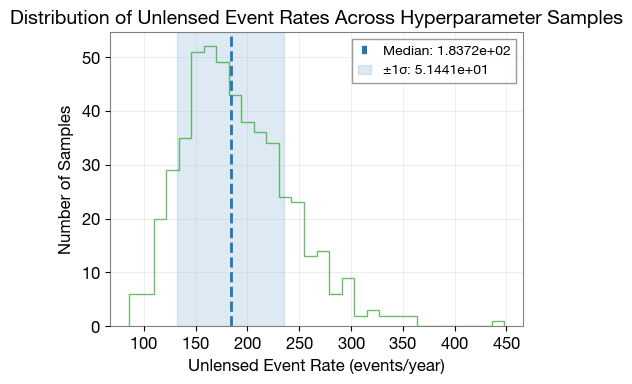

In [28]:
median_rate = np.median(rate)
std_rate = np.std(rate)

plt.figure(figsize=(5, 4))
plt.hist(rate, bins=30, color='C2', alpha=0.7, histtype='step')

plt.axvline(
    median_rate,
    color='C0',
    linestyle='dashed',
    linewidth=2,
    label=f'Median: {median_rate:.4e}'
)
plt.axvspan(
    median_rate - std_rate,
    median_rate + std_rate,
    color='C0',
    alpha=0.15,
    label=f'±1σ: {std_rate:.4e}'
)

plt.xlabel('Unlensed Event Rate (events/year)', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.title('Distribution of Unlensed Event Rates Across Hyperparameter Samples', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()